<a href="https://colab.research.google.com/github/Santiago-Parada/Public-Projects/blob/Regression-FS-%2B-Model-Fit%2BPerformance/ProyectoRegresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: center;">

<h1 style="font-size: 3em; margin-bottom: 0.2em;">Default of Credit Card Clients</h1>

<h3 style="margin-top: 0; margin-bottom: 1em;">Santiago Pérez Parada</h3>

<p style="font-size: 1.2em; margin-top: 0;">13 de agosto de 2025</p>

</div>




Objetivo: Predecir la probabilidad de que un cliente de tarjeta de crédito no pague en el próximo mes mediante una regresión logit. La información que se tiene es de Tailandia en el 2005.

# Importar información

In [1]:
# !pip install -U scikit-learn

In [2]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.inspection import PartialDependenceDisplay
from scipy.stats import ks_2samp
from scipy.stats import chi2
from IPython.display import Latex
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score
le = LabelEncoder()

ts=0.3
rs=123
ri=0.95
iv=0.1
csi_th=0.1
cor=0.7
pval=0.05
vf=5
max_unique=15
#data = fetch_openml(data_id=45016, as_frame=True)
data=pd.read_excel("sample_data/default of credit card clients.xls").drop(columns=['Unnamed: 0'])
data=data.iloc[1:]
object_cols = data.select_dtypes(include=['object']).columns
data[object_cols] = data[object_cols].astype(float)
X = data.drop(columns=['Y'])
y = data['Y']



In [3]:
##INPUT MANUAL POR DIFERENCIAS EN LA INFORMACIÓN
X['X3']=X['X3'].replace({0:4,5:4,6:4})
X['X4']=X['X4'].replace({0:3})

In [4]:
for i in X.columns:
  if 2<=X[i].nunique() and X[i].nunique() <=max_unique:
    print(i,X[i].unique())


X2 [2. 1.]
X3 [2. 1. 3. 4.]
X4 [1. 2. 3.]
X6 [ 2. -1.  0. -2.  1.  3.  4.  8.  7.  5.  6.]
X7 [ 2.  0. -1. -2.  3.  5.  7.  4.  1.  6.  8.]
X8 [-1.  0.  2. -2.  3.  4.  6.  7.  1.  5.  8.]
X9 [-1.  0. -2.  2.  3.  4.  5.  7.  6.  1.  8.]
X10 [-2.  0. -1.  2.  3.  5.  4.  7.  8.  6.]
X11 [-2.  2.  0. -1.  3.  6.  4.  7.  8.  5.]


Queremos un modelo con la siguiente relación:

 $$\log\left( \frac{p}{1 - p} \right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k $$

In [5]:
Markdown(f"""# Random Forest
Descripción: se ajusta un random forest y nos quedamos las variables que acumulan el {round(ri*100,0)}%""")

# Random Forest
Descripción: se ajusta un random forest y nos quedamos las variables que acumulan el 95.0%

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=ts, stratify=y, random_state=111
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=rs))
])
param_grid = {
    "rf__n_estimators": [250],
    "rf__max_depth": [10],
    "rf__max_samples": [0.8],  # Tamaño de la muestra por árbol
    "rf__bootstrap": [True],      # Usar muestreo con reemplazo
    "rf__min_samples_split": [2],  # Número mínimo de muestras para dividir un nodo
    "rf__min_samples_leaf": [0.05],   # Número mínimo de muestras en una hoja
    "rf__random_state": [rs]# Semilla aleatoria
}


grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)





Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__bootstrap': [True], 'rf__max_depth': [10], 'rf__max_samples': [0.8], 'rf__min_samples_leaf': [0.05], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

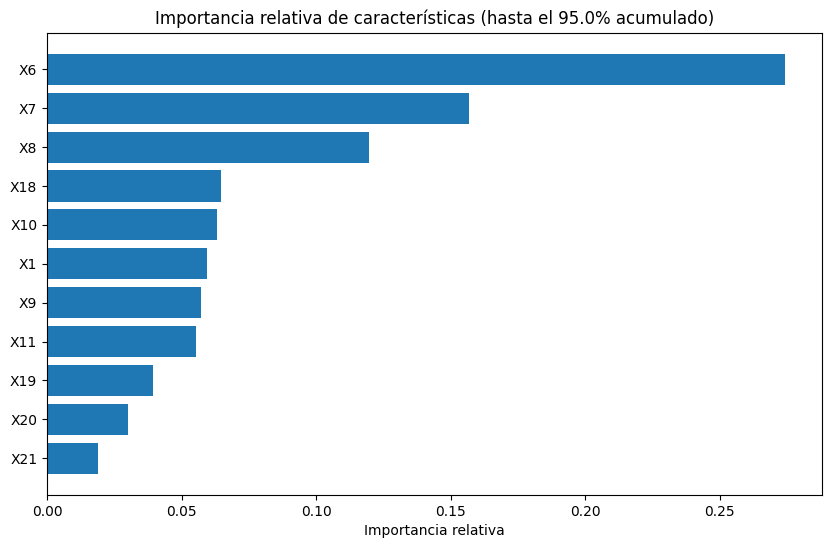

In [7]:

importances = grid_search.best_estimator_.named_steps['rf'].feature_importances_

importances_normalized = importances / importances.sum()

indices = np.argsort(importances_normalized)[::-1]

cumulative_importance = np.cumsum(importances_normalized[indices])

selected_indices = indices[cumulative_importance <= ri ]

# Crear gráfico
plt.figure(figsize=(10, 6))
plt.barh(range(len(selected_indices)), importances_normalized[selected_indices], align='center')
plt.yticks(range(len(selected_indices)), X.columns[selected_indices])
plt.xlabel('Importancia relativa')
plt.title(f'Importancia relativa de características (hasta el {ri*100}% acumulado)')
plt.gca().invert_yaxis()
plt.show()



In [8]:


col_list = X.columns[selected_indices].dropna().unique().tolist()
X=X[col_list]
X_train=X_train[col_list]
X_test=X_test[col_list]




In [9]:
Markdown(fr"""# Information Value
Descripicion: Calculamos el information value (estadístico de predictibilidad de las características) quedándonos solo con las que tienen un IV mayor del {iv*100}%""")

# Information Value
Descripicion: Calculamos el information value (estadístico de predictibilidad de las características) quedándonos solo con las que tienen un IV mayor del 10.0%

In [10]:

def iv_and_woe(X, y, bins=10):

    data = pd.concat([X, y], axis=1)
    data.columns = [X.name, y.name]

    # Binarizar la variable si es numérica
    if np.issubdtype(X.dtype, np.number):
        data['bin'] = pd.qcut(data[X.name], bins, duplicates='drop')
    else:
        data['bin'] = data[X.name]

    # Calcular los eventos y no eventos por bin
    grouped = data.groupby('bin').agg({y.name: ['count', 'sum']})
    grouped.columns = ['total', 'good']
    grouped['bad'] = grouped['total'] - grouped['good']
    grouped['good_dist'] = grouped['good'] / grouped['good'].sum()
    grouped['bad_dist'] = grouped['bad'] / grouped['bad'].sum()
    grouped['woe'] = np.log(grouped['good_dist'] / grouped['bad_dist'])
    grouped['iv'] = (grouped['good_dist'] - grouped['bad_dist']) * grouped['woe']

    # Calcular el IV total
    iv_total = grouped['iv'].sum()
    return {'Variable': X.name, 'IV': iv_total}, grouped[['woe']]

iv_list = []
woe_list = []
for k in X.columns:
  i,j=iv_and_woe(X_train[k], y_train, bins=10)
  iv_list.append(i)
  woe_list.append(j)

iv_df = pd.DataFrame(iv_list)
iv_df = iv_df.sort_values(by='IV', ascending=False)

woe_df = pd.concat(woe_list, axis=1)
woe_df.columns = iv_df['Variable']
iv_df
iv_df=iv_df[iv_df["IV"]>iv]



/tmp/ipython-input-739322529.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin').agg({y.name: ['count', 'sum']})
/tmp/ipython-input-739322529.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin').agg({y.name: ['count', 'sum']})
/tmp/ipython-input-739322529.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin').agg({y.name: ['count', '

In [11]:
iv_df=iv_df[iv_df["IV"]>iv]
print("Variables seleccionadas")
iv_df



Variables seleccionadas


,Variable,IV
0,X6,0.861794
1,X7,0.550136
2,X8,0.418344
6,X9,0.355016
4,X10,0.318673
7,X11,0.285853
5,X1,0.174498
3,X18,0.163061
8,X19,0.141648
9,X20,0.119258


In [12]:
col_list = iv_df['Variable'].dropna().unique().tolist()
X=X[col_list]
X_train=X_train[col_list]
X_test=X_test[col_list]



In [13]:
Markdown(fr"""# CSI
Descripcion: Calculamos el Caracthericstic Stability Index (estadístico de estabilidad para características) quedándonos con las menores a {csi_th*100}%
""")

# CSI
Descripcion: Calculamos el Caracthericstic Stability Index (estadístico de estabilidad para características) quedándonos con las menores a 10.0%


In [14]:
def psi(expected_series, actual_series, n_bins=10):
    bins = pd.qcut(expected_series, q=n_bins, duplicates='drop', retbins=True)[1]
    expected_binned = pd.cut(expected_series, bins=bins, include_lowest=True)
    actual_binned = pd.cut(actual_series, bins=bins, include_lowest=True)

    expected_dist = expected_binned.value_counts(normalize=True).sort_index()
    actual_dist = actual_binned.value_counts(normalize=True).sort_index()

    psi = ((expected_dist - actual_dist) * np.log(expected_dist / actual_dist)).sum()
    return psi
df=[]
for i in X.columns:
  df.append([i,psi(X_train[i],X_test[i])])

csi=pd.DataFrame(df,columns=["variable","csi"])
csi

,variable,csi
0,X6,0.000168
1,X7,0.000256
2,X8,0.000178
3,X9,0.000491
4,X10,0.000905
5,X11,0.000825
6,X1,0.000703
7,X18,0.001073
8,X19,0.001983
9,X20,0.001477


In [15]:

csi=csi[csi["csi"]<csi_th]
col_list = csi['variable'].dropna().unique().tolist()
print("Variables seleccionadas")
csi


Variables seleccionadas


,variable,csi
0,X6,0.000168
1,X7,0.000256
2,X8,0.000178
3,X9,0.000491
4,X10,0.000905
5,X11,0.000825
6,X1,0.000703
7,X18,0.001073
8,X19,0.001983
9,X20,0.001477


In [16]:
X=X[col_list]
X_train=X_train[col_list]
X_test=X_test[col_list]

In [17]:
Markdown(fr"""# Matriz de correlación
Obtenemos las correlaciones entre características, quitando aquellas que son mayores al {cor*100}%, de tal manera que se conserva la que tiene mayor IV
""")

# Matriz de correlación
Obtenemos las correlaciones entre características, quitando aquellas que son mayores al 70.0%, de tal manera que se conserva la que tiene mayor IV


In [18]:
corr=X_train.corr(method='pearson')
corr

,X6,X7,X8,X9,X10,X11,X1,X18,X19,X20
X6,1.000000,0.672343,0.576516,0.541378,0.512584,0.477091,-0.267880,-0.073931,-0.068277,-0.065182
X7,0.672343,1.000000,0.772021,0.665163,0.626327,0.578071,-0.289686,-0.073676,-0.055179,-0.049366
X8,0.576516,0.772021,1.000000,0.777515,0.684893,0.633086,-0.280421,0.004845,-0.062506,-0.048022
X9,0.541378,0.665163,0.777515,1.000000,0.816009,0.708716,-0.266722,-0.004309,-0.002001,-0.067112
X10,0.512584,0.626327,0.684893,0.816009,1.000000,0.811843,-0.246165,-0.001659,-0.003120,0.010232
X11,0.477091,0.578071,0.633086,0.708716,0.811843,1.000000,-0.231075,0.004614,-0.004915,0.008239
X1,-0.267880,-0.289686,-0.280421,-0.266722,-0.246165,-0.231075,1.000000,0.193131,0.172252,0.208705
X18,-0.073931,-0.073676,0.004845,-0.004309,-0.001659,0.004614,0.193131,1.000000,0.327514,0.280162
X19,-0.068277,-0.055179,-0.062506,-0.002001,-0.003120,-0.004915,0.172252,0.327514,1.000000,0.268342
X20,-0.065182,-0.049366,-0.048022,-0.067112,0.010232,0.008239,0.208705,0.280162,0.268342,1.000000


In [20]:
pairs = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > cor:
            pairs.append([
                corr.columns[i],
                corr.columns[j],
                corr.iloc[i, j]
            ])
df=pd.DataFrame(pairs,columns=["var1","var2","correlation"])
df
df=df.drop("correlation",axis=1)
df = df.merge(iv_df, left_on='var1', right_on='Variable', how='left') \
                       .rename(columns={'IV': 'IV_var1'}).drop('Variable', axis=1)

df = df.merge(iv_df, left_on='var2', right_on='Variable', how='left') \
                       .rename(columns={'IV': 'IV_var2'}).drop('Variable', axis=1)

In [21]:
df['eliminar'] = df.apply(
    lambda row: row['var1'] if row['IV_var1'] < row['IV_var2'] else row['var2'],
    axis=1
)
df["eliminar"]


,eliminar
0,X8
1,X9
2,X10
3,X11
4,X11


In [22]:
df=df["eliminar"].dropna().unique().tolist()
X=X.drop(columns=df)
X_train=X_train.drop(columns=df)
X_test=X_test.drop(columns=df)

# Outlier treatment(1-99 cap) transformación lineal (Normalización) y manejo de variables dicotómica y categóricas

Descripción: se aplica una corrección sobre los outliers (los que están fuera de del primer o 99 percentil se limitan al primer y 99 percentil) y una
transformación "Normalizar" la cúal es rescala las variables para que no influya la diferencia de escalas

In [23]:
for i in X.columns:
  X[i] = X[i].clip(X_train[i].quantile(0.01), X_train[i].quantile(0.99))
  X_train[i] = X_train[i].clip(X_train[i].quantile(0.01), X_train[i].quantile(0.99))
  X_test[i] = X_test[i].clip(X_train[i].quantile(0.01), X_train[i].quantile(0.99))



In [24]:
for i in X.columns:
  if 2<=X[i].nunique() and X[i].nunique() <=max_unique:
    print(i,X[i].unique())

X6 [ 2. -1.  0. -2.  1.  3.]
X7 [ 2.  0. -1. -2.  3.  1.]


In [25]:
lis=[]
for i in X.columns:
  if X[i].nunique()>max_unique:
    lis.append(i)
X[lis] = X[lis].apply(
    lambda col: (col - col.min()) / (col.max() - col.min())
)
X_train[lis] = X_train[lis].apply(
    lambda col: (col - col.min()) / (col.max() - col.min())
)
X_test[lis] = X_test[lis].apply(
    lambda col: (col - col.min()) / (col.max() - col.min())
)

In [26]:
Markdown(fr"""# Backward Stepwise Selection
Descripción: Se realiza una selección de variables, de tal manera que se eliminan la variable con mayor valor p en cada iteración hasta que todas
las variables tengan un valor p menor de {pval*100}%
""")

# Backward Stepwise Selection
Descripción: Se realiza una selección de variables, de tal manera que se eliminan la variable con mayor valor p en cada iteración hasta que todas
las variables tengan un valor p menor de 5.0%


In [27]:
def backward_stepwise_selection(
    X,
    y,
    threshold_out,
    max_unique=5,
    verbose=True
):
    X = X.copy()

    binary_vars = []
    categorical_blocks = {}
    continuous_vars = []

    col_to_original = {}  # mapping column -> original variable

    for col in X.columns:
        nunique = X[col].nunique()

        if nunique == 2:
            binary_vars.append(col)
            col_to_original[col] = col
            X[col] = le.fit_transform(X[col])

        elif 3 <= nunique <= max_unique:
            dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
            categorical_blocks[col] = list(dummies.columns)
            for d in dummies.columns:
                col_to_original[d] = col
            X = X.drop(columns=col).join(dummies)

        else:
            continuous_vars.append(col)
            col_to_original[col] = col


    X = sm.add_constant(X)
    remaining_cols = list(X.columns)
    history = []

    while True:
        X[remaining_cols] = X[remaining_cols].astype(float)
        model_full = sm.Logit(y, X[remaining_cols]).fit(disp=0)

        candidates = []

        # Continuous and binary → Wald
        for col in remaining_cols:
            if col == "const":
                continue
            if col in binary_vars or col in continuous_vars:
                candidates.append({
                    "type": "single",
                    "name": col,
                    "cols": [col],
                    "pval": model_full.pvalues[col],
                    "original": col_to_original[col]
                })

        # Categorical → LRT per block
        for var, dummies in categorical_blocks.items():
            dummies_in_model = [d for d in dummies if d in remaining_cols]
            if not dummies_in_model:
                continue

            reduced_cols = [c for c in remaining_cols if c not in dummies_in_model]
            model_reduced = sm.Logit(y, X[reduced_cols]).fit(disp=0)

            lr_stat = 2 * (model_full.llf - model_reduced.llf)
            df = len(dummies_in_model)
            pval = chi2.sf(lr_stat, df)

            candidates.append({
                "type": "block",
                "name": var,
                "cols": dummies_in_model,
                "pval": pval,
                "original": var
            })

        # Select worst candidate
        worst = max(candidates, key=lambda x: x["pval"])

        if worst["pval"] > threshold_out:
            for c in worst["cols"]:
                remaining_cols.remove(c)

            history.append({
                "removed": worst["original"],  # original variable name
                "type": worst["type"],
                "p_value": worst["pval"],
                "n_vars": len(remaining_cols) - 1
            })

            if verbose:
                print(f"Removed {worst['original']} ({worst['type']}, p = {worst['pval']:.4f})")
        else:
            if verbose:
                print("No variables exceed p-value threshold. Stepwise finished.")
            break

    # Return original variable names for selected columns
    selected_vars = list({col_to_original[c] for c in remaining_cols if c != "const"})
    history_df = pd.DataFrame(history)
    candidates=pd.DataFrame(candidates)

    return selected_vars, history_df,candidates

rv,hd,cand=backward_stepwise_selection(X_train, y_train,pval,max_unique,verbose=True)

No variables exceed p-value threshold. Stepwise finished.


In [28]:
""" # Select worst candidate
        worst = max(candidates, key=lambda x: x["pval"])

        if worst["pval"] > threshold_out:
            for c in worst["cols"]:
                remaining_cols.remove(c)

            history.append({
                "removed": worst["original"],  # original variable name
                "type": worst["type"],
                "p_value": worst["pval"],
                "n_vars": len(remaining_cols) - 1
            })

            if verbose:
                print(f"Removed {worst['original']} ({worst['type']}, p = {worst['pval']:.4f})")
        else:
            if verbose:
                print("No variables exceed p-value threshold. Stepwise finished.")
            break

    # Return original variable names for selected columns
    selected_vars = list({col_to_original[c] for c in remaining_cols if c != "const"})
    history_df = pd.DataFrame(history)
    candidates=pd.DataFrame(candidates)"""


' # Select worst candidate\n        worst = max(candidates, key=lambda x: x["pval"])\n\n        if worst["pval"] > threshold_out:\n            for c in worst["cols"]:\n                remaining_cols.remove(c)\n\n            history.append({\n                "removed": worst["original"],  # original variable name\n                "type": worst["type"],\n                "p_value": worst["pval"],\n                "n_vars": len(remaining_cols) - 1\n            })\n\n            if verbose:\n                print(f"Removed {worst[\'original\']} ({worst[\'type\']}, p = {worst[\'pval\']:.4f})")\n        else:\n            if verbose:\n                print("No variables exceed p-value threshold. Stepwise finished.")\n            break\n\n    # Return original variable names for selected columns\n    selected_vars = list({col_to_original[c] for c in remaining_cols if c != "const"})\n    history_df = pd.DataFrame(history)\n    candidates=pd.DataFrame(candidates)'

In [29]:

X=X[rv]
X_train=X_train[rv]
X_test=X_test[rv]
cand

,type,name,cols,pval,original
0,single,X1,[X1],3.034985e-18,X1
1,single,X18,[X18],1.356379e-04,X18
2,single,X19,[X19],4.871924e-08,X19
3,single,X20,[X20],1.454203e-03,X20
4,block,X6,"[X6_-1.0, X6_0.0, X6_1.0, X6_2.0, X6_3.0]",1.693555e-250,X6
5,block,X7,"[X7_-1.0, X7_0.0, X7_1.0, X7_2.0, X7_3.0]",1.701567e-22,X7


In [30]:
Markdown(fr"""# VIF
Descripción: El VIF es un estadístico que mide la multicolinealidad entre las características, por tanto se eliminan aquellos con un VIF mayor a {vf}""")

# VIF
Descripción: El VIF es un estadístico que mide la multicolinealidad entre las características, por tanto se eliminan aquellos con un VIF mayor a 5

In [31]:


def multivariate_r2_trace(Y, X):
    """
    Trace-based multivariate R^2
    """
    Y = np.asarray(Y)
    X = np.asarray(X)

    SS_res = 0.0
    SS_tot = 0.0

    for j in range(Y.shape[1]):
        y_col = Y[:, j]
        model = sm.OLS(y_col, X).fit()
        resid = model.resid
        SS_res += np.sum(resid**2)
        SS_tot += np.sum((y_col - y_col.mean())**2)

    return 1.0 - SS_res / SS_tot


def vif(
    X,
    threshold=5.0,
    max_unique=5,
    verbose=True
):
    X = X.copy()

    binary_vars = []
    categorical_blocks = {}
    continuous_vars = []

    col_to_original = {}

    for col in X.columns:
        nunique = X[col].nunique()

        if nunique == 2:
            binary_vars.append(col)
            col_to_original[col] = col
            X[col] = le.fit_transform(X[col])

        elif 3 <= nunique <= max_unique:
            dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
            categorical_blocks[col] = list(dummies.columns)
            for d in dummies.columns:
                col_to_original[d] = col
            X = X.drop(columns=col).join(dummies)

        else:
            continuous_vars.append(col)
            col_to_original[col] = col
    X = sm.add_constant(X)
    X = X.astype(float)

    remaining_cols = list(X.columns)
    history = []

    while True:
        vif_list = []

        # Continuous/binary
        for col in continuous_vars + binary_vars:
            if col not in remaining_cols:
                continue
            idx = X.columns.get_loc(col)
            v = variance_inflation_factor(X[remaining_cols].values, remaining_cols.index(col))
            vif_list.append({
                "type": "continuous/binary",
                "variable": col,
                "VIF": v
            })

        # Categorical blocks
        for var, dummies in categorical_blocks.items():
            dummies_in_X = [d for d in dummies if d in remaining_cols]
            if not dummies_in_X:
                continue
            Y_block = X[dummies_in_X]
            X_others = X[remaining_cols].drop(columns=dummies_in_X)
            R2_multi = multivariate_r2_trace(Y_block, X_others)
            v = 1.0 / (1 - R2_multi)
            vif_list.append({
                "type": "categorical",
                "variable": var,
                "VIF": v
            })

        # Convert to DataFrame
        vif_df = pd.DataFrame(vif_list)
        if vif_df.empty:
            break

        # Find worst variable
        worst_idx = vif_df["VIF"].idxmax()
        worst_var = vif_df.loc[worst_idx, "variable"]
        worst_vif = vif_df.loc[worst_idx, "VIF"]

        if worst_vif > threshold:
            # Remove variable (all dummies if categorical)
            if worst_var in categorical_blocks:
                cols_to_remove = [d for d in categorical_blocks[worst_var] if d in remaining_cols]
            else:
                cols_to_remove = [worst_var]

            for c in cols_to_remove:
                remaining_cols.remove(c)

            history.append({
                "removed": worst_var,
                "type": vif_df.loc[worst_idx, "type"],
                "VIF": worst_vif,
                "n_vars_remaining": len(remaining_cols) - 1  # exclude const
            })

            if verbose:
                print(f"Removed {worst_var} ({vif_df.loc[worst_idx, 'type']}) with VIF = {worst_vif:.2f}")
        else:
            # No more variables above threshold
            break

    # Return results
    selected_vars = list(set([col_to_original.get(c, c) for c in remaining_cols if c != "const"]))
    history_df = pd.DataFrame(history)

    return selected_vars, history_df,vif_df
col_list,hist,vif=vif(X_train,vf,max_unique)

In [32]:

X=X[col_list]
X_test=X_test[col_list]
X_train=X_train[col_list]
vif

,type,variable,VIF
0,continuous/binary,X20,1.184880
1,continuous/binary,X18,1.244508
2,continuous/binary,X1,1.280601
3,continuous/binary,X19,1.213094
4,categorical,X7,2.665080
5,categorical,X6,2.128476


# Ajuste de modelo logit

In [33]:
model = LogisticRegression(max_iter=1000, solver='liblinear')

binary_vars = []
categorical_blocks = {}
continuous_vars = []

col_to_original = {}

for col in X.columns:
  nunique = X[col].nunique()

  if nunique == 2:
      binary_vars.append(col)
      col_to_original[col] = col
      X[col] = le.fit_transform(X[col])
      X_train[col] = le.fit_transform(X_train[col])
      X_test[col] = le.fit_transform(X_test[col])

  elif 3 <= nunique <= max_unique:
      dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
      categorical_blocks[col] = list(dummies.columns)
      for d in dummies.columns:
          col_to_original[d] = col
      X = X.drop(columns=col).join(dummies)
      X_test = X_test.drop(columns=col).join(dummies)
      X_train = X_train.drop(columns=col).join(dummies)

  else:
      continuous_vars.append(col)
      col_to_original[col] = col
model.fit(X_train,y_train)





,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# PDP'S y Bi variate
Descripción: Los partial dependency plots nos ayudan a observar que en efecto se cumpla la relación lineal entre características y target (se grafica el score o probabilidad asociada con las características)

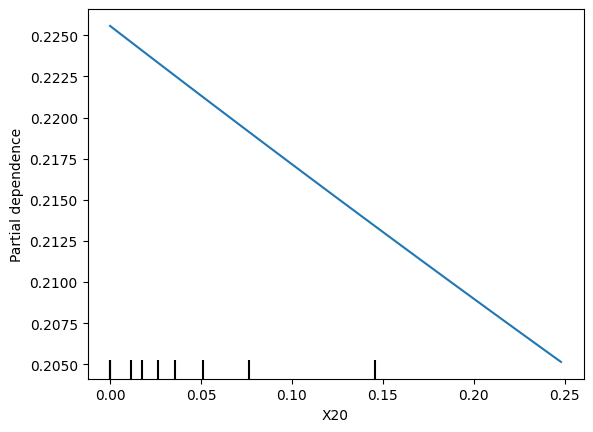

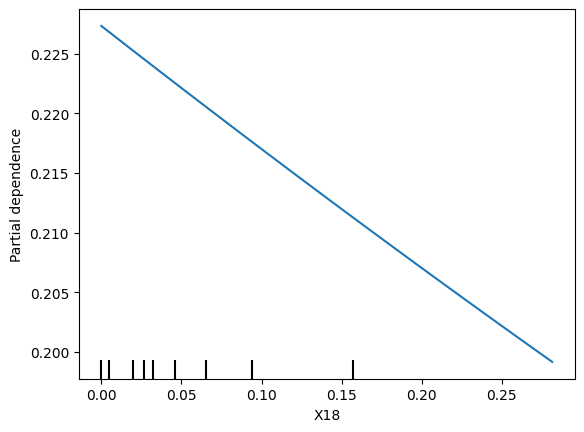

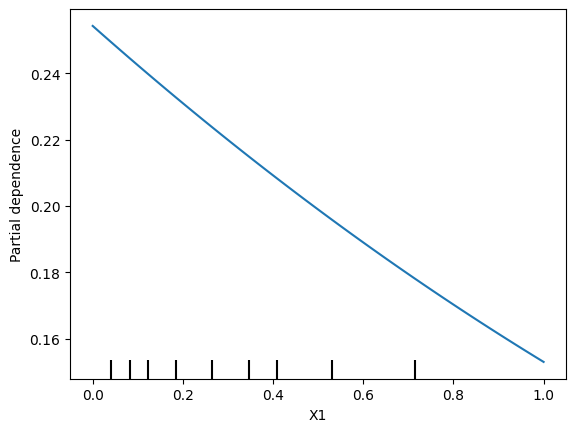

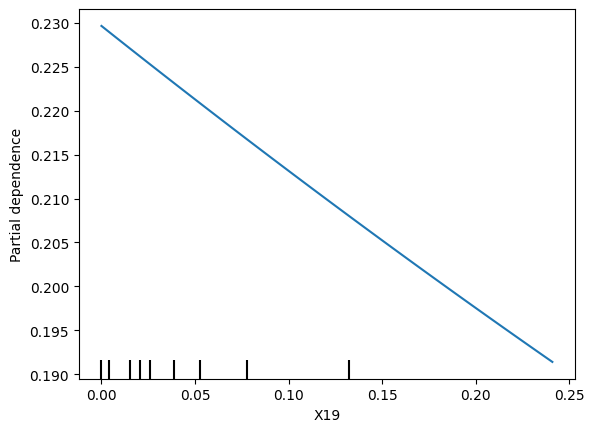

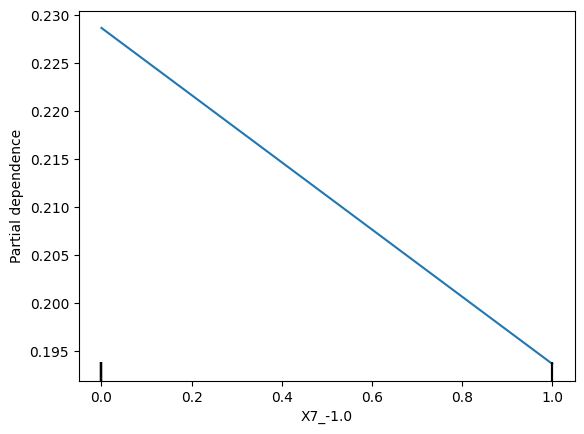

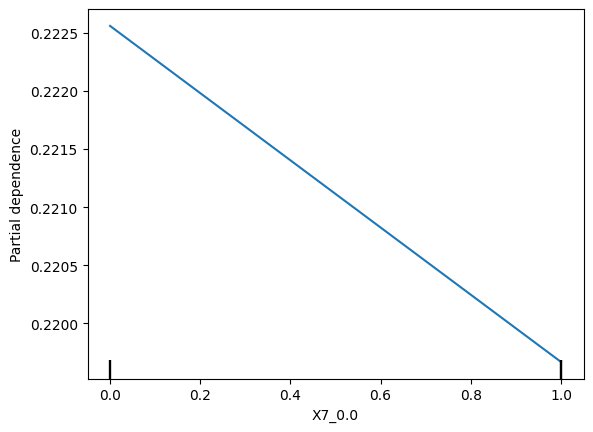

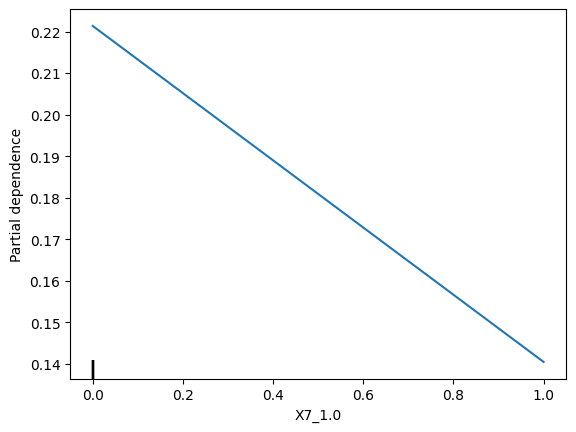

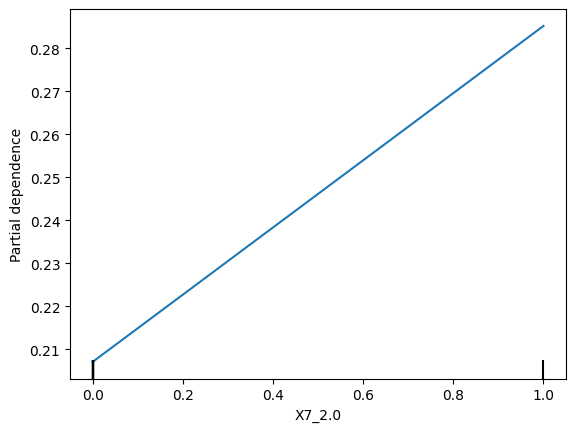

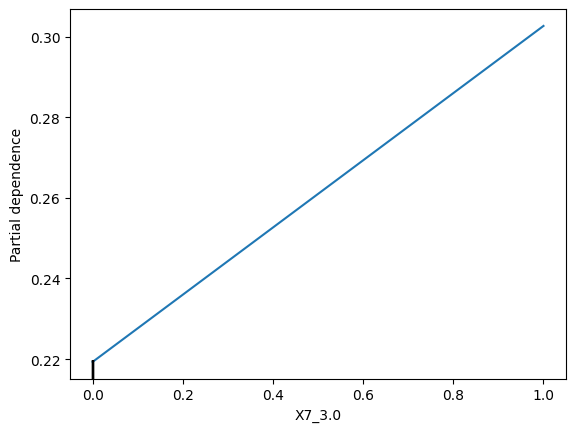

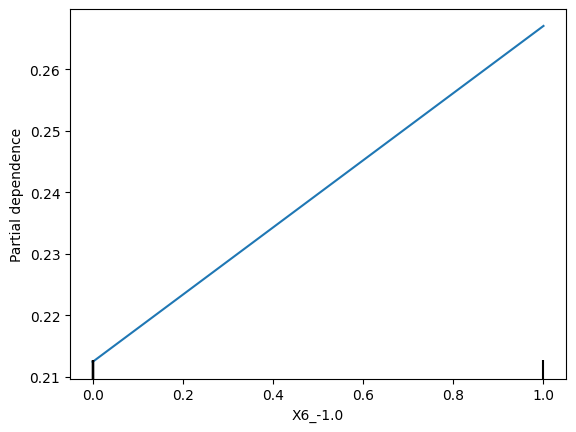

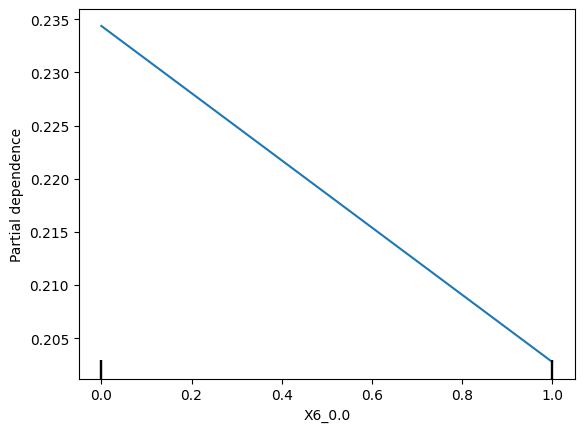

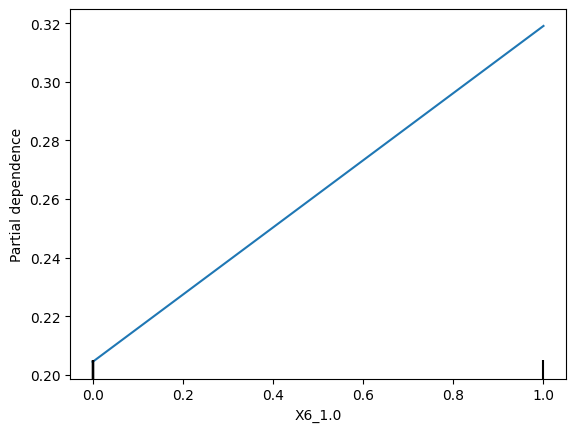

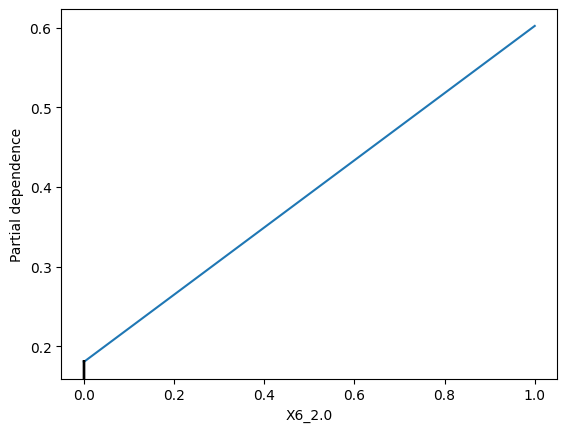

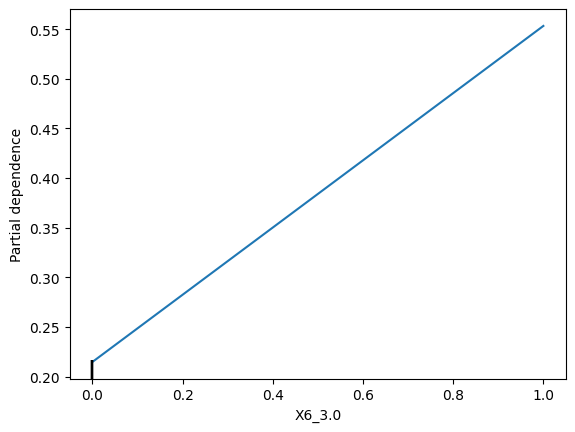

In [34]:
X_train=X_train.astype(float)
for i in X.columns:
  try:
    PartialDependenceDisplay.from_estimator(model, X_train, [i])
    plt.show()
  except:
    print(X[i].nunique())
    PartialDependenceDisplay.from_estimator(model, X_train, [i],kind='average', grid_resolution=10)
    plt.show()



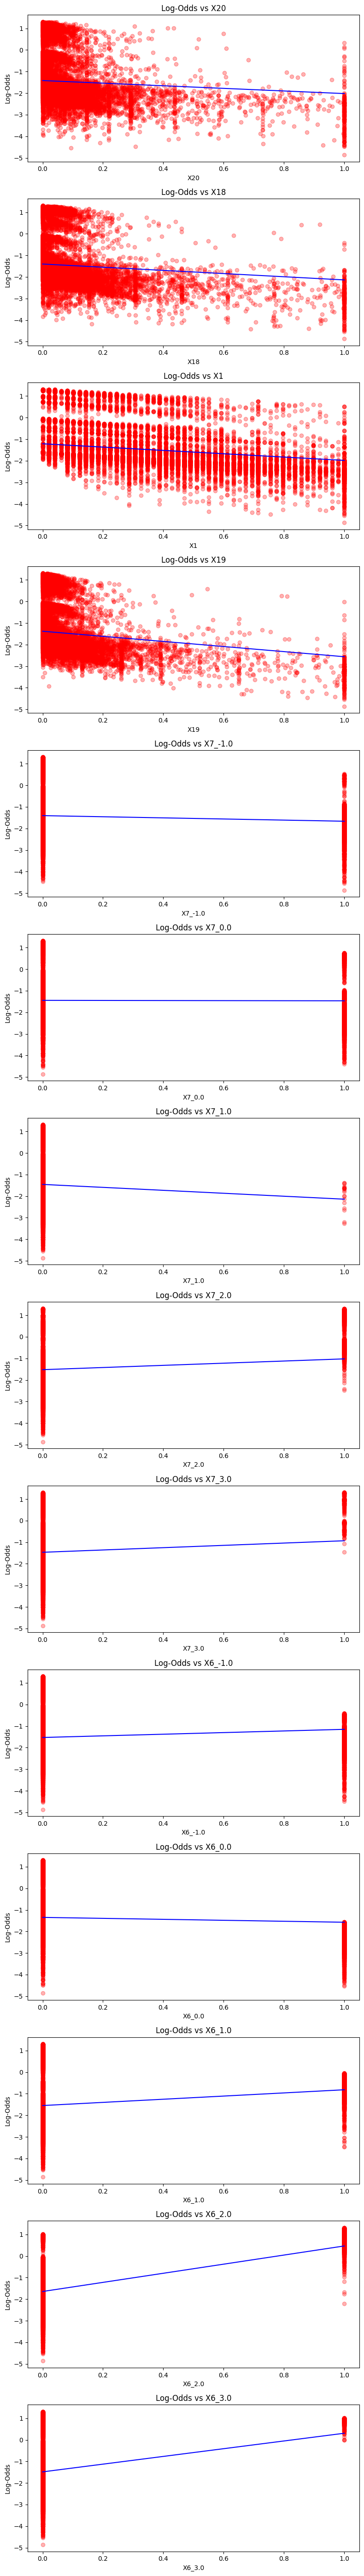

In [35]:
features = X.columns.tolist()

# Plot all 1D PDPs in log-odds
fig, ax = plt.subplots(len(features), 1, figsize=(8, 4*len(features)))

for i, feature in enumerate(features):
    # Grid for the feature
    feature_values = np.linspace(X_train[feature].min(), X_train[feature].max(), 10000)

    # Fix other features at their mean
    grid_df = pd.DataFrame(
    {col: X[col].mean() for col in X.columns},
    index=np.arange(len(feature_values)))
    grid_df[feature] = feature_values

  # Predict log-odds
    log_odds = model.decision_function(grid_df)

    # Plot
    ax[i].plot(feature_values, log_odds, color='blue')
    ax[i].scatter(X_train[feature], model.decision_function(X_train), color='red', alpha=0.3)
    ax[i].set_xlabel(feature)
    ax[i].set_ylabel('Log-Odds')
    ax[i].set_title(f'Log-Odds vs {feature}')

plt.tight_layout()
plt.show()

# Modelo Final
Descripción: tenemos las caracterísitcas finales.

In [36]:

coeficientes = model.coef_[0]


intercepto = model.intercept_[0]

nombres_variables = X.columns


In [37]:
df=[]
for nombre, coef in zip(nombres_variables, coeficientes):
    df.append( [nombre,coef])
df.append(["Intercepto",intercepto])
pd.DataFrame(df, columns=["variables","coeficients"])



,variables,coeficients
0,X20,-0.603673
1,X18,-0.736845
2,X1,-0.770957
3,X19,-1.180989
4,X7_-1.0,-0.259624
5,X7_0.0,-0.020827
6,X7_1.0,-0.684397
7,X7_2.0,0.500799
8,X7_3.0,0.534306
9,X6_-1.0,0.377763


In [38]:
X_train = sm.add_constant(X_train)
remaining_cols = list(X_train.columns)
X_train=X_train.astype(float)
model_full = sm.Logit(y_train, X_train[remaining_cols]).fit(disp=0)
candidates=[]

# Continuous and binary → Wald
for col in remaining_cols:
    if col == "const":
        continue
    if col in binary_vars or col in continuous_vars:
        candidates.append({
            "type": "single",
            "name": col,
            "cols": [col],
            "pval": model_full.pvalues[col],
            "coefficient":model_full.params[col]
        })

# Categorical → LRT per block
for var, dummies in categorical_blocks.items():
    dummies_in_model = [d for d in dummies if d in remaining_cols]
    if not dummies_in_model:
        continue

    reduced_cols = [c for c in remaining_cols if c not in dummies_in_model]
    model_reduced = sm.Logit(y_train, X_train[reduced_cols]).fit(disp=0)

    lr_stat = 2 * (model_full.llf - model_reduced.llf)
    df = len(dummies_in_model)
    pval = chi2.sf(lr_stat, df)
    for i in dummies_in_model:
      candidates.append({
                  "type": "block",
                  "name": var,
                  "cols": i,
                  "pval": pval,
                  "coefficient":model_full.params[i]
              })
pd.DataFrame(candidates).sort_values(by="pval")

,type,name,cols,pval,coefficient
12,block,X6,X6_2.0,1.693555e-250,2.172806
11,block,X6,X6_1.0,1.693555e-250,0.780047
10,block,X6,X6_0.0,1.693555e-250,-0.166563
13,block,X6,X6_3.0,1.693555e-250,1.872122
9,block,X6,X6_-1.0,1.693555e-250,0.433413
7,block,X7,X7_2.0,1.701567e-22,0.472563
5,block,X7,X7_0.0,1.701567e-22,-0.051671
6,block,X7,X7_1.0,1.701567e-22,-1.041887
4,block,X7,X7_-1.0,1.701567e-22,-0.286761
8,block,X7,X7_3.0,1.701567e-22,0.503706


# Performance
Descripción: performance del modelo final

# Cutoff selection
Descripción: Seleccionar el mejor cutoff que maximize f1 score

In [39]:

def best_f1_cutoff(y_true, y_proba, steps=1001):
    """
    Encuentra el cutoff que maximiza el F1 score.

    Parameters
    ----------
    y_true : array-like
        Etiquetas reales (0/1)
    y_proba : array-like
        Probabilidades predichas de la clase positiva
    steps : int
        Cantidad de cutoffs a evaluar entre 0 y 1

    Returns
    -------
    best_cutoff : float
        Cutoff que maximiza F1
    best_f1 : float
        Mejor F1 obtenido
    """
    cutoffs = np.linspace(0, 1, steps)
    f1_scores = []

    for c in cutoffs:
        y_pred = (y_proba >= c).astype(int)
        f1_scores.append(f1_score(y_true, y_pred))

    best_idx = np.argmax(f1_scores)
    return cutoffs[best_idx], f1_scores[best_idx]


In [40]:
X_train=X_train.drop('const',axis=1)
#X_test=X_test.drop('const',axis=1)
y_proba_train = model.predict_proba(X_train)[:, 1]
y_proba_test = model.predict_proba(X_test)[:, 1]
cutoff,f1 = best_f1_cutoff(y_train, y_proba_train, steps=1001)
y_pred = (y_proba_test >= cutoff).astype(int)
cutoff,f1

(np.float64(0.232), 0.5247116096941475)

In [41]:
X_train.columns

Index(['X20', 'X18', 'X1', 'X19', 'X7_-1.0', 'X7_0.0', 'X7_1.0', 'X7_2.0',
       'X7_3.0', 'X6_-1.0', 'X6_0.0', 'X6_1.0', 'X6_2.0', 'X6_3.0'],
      dtype='object')

## Matriz de confusión
Descripción: Muestra en nuetro conjunto de test, que tan preciso y predictivo es nuestro modelo

In [42]:
pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).transpose()

,precision,recall,f1-score,support
0.0,0.866155,0.854045,0.860057,7009.000000
1.0,0.510292,0.535409,0.522549,1991.000000
accuracy,0.783556,0.783556,0.783556,0.783556
macro avg,0.688224,0.694727,0.691303,9000.000000
weighted avg,0.787431,0.783556,0.785393,9000.000000


## Kolmogorov-Smirnov Statistic
Descripción: estadístico que nos sirve para medir que tan distinta es la distirbución acumulada de una población contra otra, en este caso que tan bien nos ayuda a distinguir entre los que pagan y no (0,1)

In [43]:
score=pd.DataFrame(np.stack((model.predict_proba(X_train)[:,1],y_train),axis=1))
score.columns=["score","target"]
ks_stat, p_value = ks_2samp(score[score["target"] == 0]["score"], score[score["target"] == 1]["score"])

display(Latex(fr"$KS \ Training = {round(ks_stat*100,2)}\% $"))

<IPython.core.display.Latex object>

In [44]:
score2=pd.DataFrame(np.stack((model.predict_proba(X_test)[:,1],y_test),axis=1))
score2.columns=["score","target"]
ks_stat, p_value = ks_2samp(score2[score2["target"] == 0]["score"], score2[score2["target"] == 1]["score"])
display(Latex(fr"$KS \ Test = {round(ks_stat*100,2)}\% $"))

<IPython.core.display.Latex object>

## PSI
Descripción: el Population Stability Index, es el mismo estadístico que CSI, aquí nos ayuda a observar si el score de entrenamiento es estable respecto al score de test

In [45]:
psi=psi(score["score"],score2["score"])
display(Latex(fr"$PSI = {round(psi*100,2)}\% $"))


<IPython.core.display.Latex object>

## Information Value
Descripción: Al igual que con las características, se aplica el IV sobre el score y la target real para medir predictibilidad

In [46]:
iv,woe=iv_and_woe(score["score"],score["target"])
iv=iv["IV"]
display(Latex(fr"$IV \ Trainning = {round(iv*100,2)}\% $"))

/tmp/ipython-input-739322529.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin').agg({y.name: ['count', 'sum']})


<IPython.core.display.Latex object>

In [47]:
iv,woe=iv_and_woe(score2["score"],score2["target"])
iv=iv["IV"]
display(Latex(fr"$IV \ Test= {round(iv*100,2)}\% $"))


/tmp/ipython-input-739322529.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin').agg({y.name: ['count', 'sum']})


<IPython.core.display.Latex object>

In [48]:
y_train.value_counts(normalize=True)


,proportion
Y,
0.0,0.77881
1.0,0.22119


In [49]:
y_test.value_counts(normalize=True)

,proportion
Y,
0.0,0.778778
1.0,0.221222
